In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv("master_influenza_dataset.csv")

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
train_region = 'Region 4'
test_region = 'Region 6'

train_data = df[df['Region'] == train_region].copy()
test_data = df[df['Region'] == test_region].copy()

train_data = train_data.sort_values('Date')
test_data = test_data.sort_values('Date')

train_data.set_index('Date', inplace=True)
test_data.set_index('Date', inplace=True)

In [ ]:
train_ts = train_data['Weighted_ILI'].fillna(method='ffill')
test_ts = test_data['Weighted_ILI'].fillna(method='ffill')

# log transform
train_log = np.log1p(train_ts)
test_log = np.log1p(test_ts)

/tmp/ipykernel_22635/741446822.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_ts = train_data['Weighted_ILI'].fillna(method='ffill')
/tmp/ipykernel_22635/741446822.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_ts = test_data['Weighted_ILI'].fillna(method='ffill')


In [ ]:
sarima_model = SARIMAX(
    train_log,
    order=(1,1,1),
    seasonal_order=(1,1,0,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
sarima_pred_log = sarima_result.predict(
    start=0,
    end=len(test_log)-1
)

sarima_pred = np.expm1(sarima_pred_log)

# align index
sarima_pred.index = test_ts.index

In [ ]:
prophet_train = train_data.reset_index()[['Date', 'Weighted_ILI']]
prophet_train.rename(columns={'Date':'ds','Weighted_ILI':'y'}, inplace=True)

model_p = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.8)
model_p.fit(prophet_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = pd.DataFrame({'ds': test_ts.index})

forecast = model_p.predict(future)

prophet_pred = forecast.set_index('ds')['yhat']

In [ ]:
transfer_df = pd.DataFrame({
    'Actual': test_ts,
    'SARIMA': sarima_pred,
    'Prophet': prophet_pred
})

transfer_df.dropna(inplace=True)

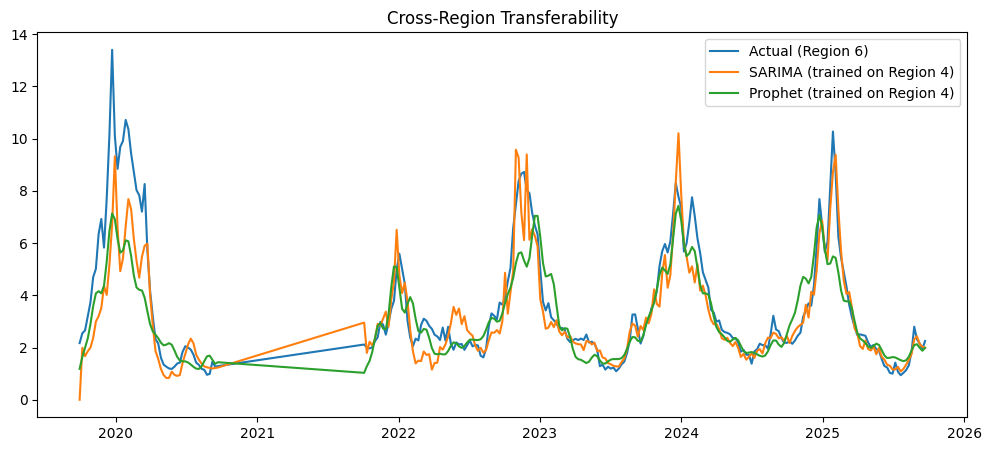

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(transfer_df.index, transfer_df['Actual'], label='Actual (Region 6)')
plt.plot(transfer_df.index, transfer_df['SARIMA'], label='SARIMA (trained on Region 4)')
plt.plot(transfer_df.index, transfer_df['Prophet'], label='Prophet (trained on Region 4)')

plt.legend()
plt.title("Cross-Region Transferability")
plt.show()

In [ ]:
rmse_sarima = np.sqrt(mean_squared_error(transfer_df['Actual'], transfer_df['SARIMA']))
rmse_prophet = np.sqrt(mean_squared_error(transfer_df['Actual'], transfer_df['Prophet']))

print("SARIMA Transfer RMSE:", rmse_sarima)
print("Prophet Transfer RMSE:", rmse_prophet)

SARIMA Transfer RMSE: 1.1652568736621256
Prophet Transfer RMSE: 1.320412678139701
